Importing libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's load and explore the dataset. This is a dataset containing information on rental properties in Bengaluru.

In [8]:
df = pd.read_csv('Bengaluru_rent.csv')
df

,seller_type,bedroom,layout_type,property_type,locality,price,area,furnish_type,bathroom
0,OWNER,2,BHK,Independent Floor,kamakshipalya,"20,000",1140,Semi-Furnished,2 bathrooms
1,OWNER,2,BHK,Independent House,Kadugodi Industrial Area,"8,000",840,Semi-Furnished,2 bathrooms
2,OWNER,2,BHK,Independent House,Koramangala,"21,000",1000,Semi-Furnished,2 bathrooms
3,OWNER,1,BHK,Apartment,Sadduguntepalya,"9,000",550,Semi-Furnished,1 bathrooms
4,OWNER,3,BHK,Apartment,Chandapura,"17,000",1230,Furnished,3 bathrooms
...,...,...,...,...,...,...,...,...,...
23535,OWNER,1,BHK,Independent Floor,Bagalakunte,"6,000",500,Semi-Furnished,1 bathrooms
23536,OWNER,2,BHK,Independent House,Vijayanagar,"10,500",400,Semi-Furnished,1 bathrooms
23537,OWNER,2,BHK,Independent House,Hennur,"16,000",1100,Semi-Furnished,2 bathrooms
23538,OWNER,2,BHK,Apartment,Shanti Nagar,"24,000",1000,Semi-Furnished,2 bathrooms


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23540 entries, 0 to 23539
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   seller_type    23540 non-null  object
 1   bedroom        23540 non-null  int64 
 2   layout_type    23540 non-null  object
 3   property_type  23540 non-null  object
 4   locality       23540 non-null  object
 5   price          23540 non-null  object
 6   area           23540 non-null  int64 
 7   furnish_type   23540 non-null  object
 8   bathroom       23106 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.6+ MB


Let's convert the price column from a string to a float so it can be used in our analysis

In [10]:
df['price'] = df['price'].str.replace(',', '').astype(float)

In [11]:
df['price']

,price
0,20000.0
1,8000.0
2,21000.0
3,9000.0
4,17000.0
...,...
23535,6000.0
23536,10500.0
23537,16000.0
23538,24000.0


Let's make a box plot of monthly charges for each type of property

/tmp/ipykernel_6830/2673100208.py:2: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


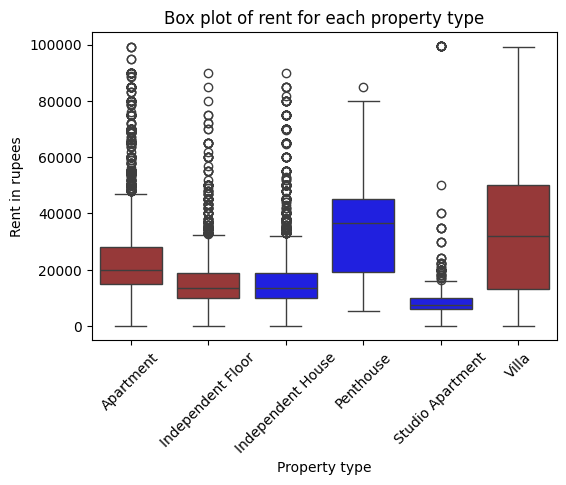

In [15]:
plt.figure(figsize = (6, 4))
sns.boxplot(
    data = df,
    x = 'property_type',
    y = 'price',
    palette=['brown', 'blue'],
    hue='property_type',
    order = sorted(list(df['property_type'].unique())),  # sorting boxes alphabetically
)
plt.title('Box plot of rent for each property type')
plt.xlabel('Property type')
plt.xticks(rotation = 45)
plt.ylabel('Rent in rupees')
plt.show()

But what does this box plot convey?

The first quartile (Q1) is the value below which 25% of our data lies; the third quartile (Q3) is the value below which 75% of our data lies. We can calculate these using the `.quantile()` method.

We can calculate potential outliers using the IQR method. The interquartile range, or IQR, is the range in which the middle 50% of the data falls. To calculate the IQR, you need to find the difference between the first and third quartiles of your data.

To remove potential outliers using the IQR method, we remove the data that is outside the following boundaries:

*   $Lower = Q1 - 1.5 \times IQR$
*   $Upper = Q3 + 1.5 \times IQR$

The Seaborn box plot considers the minimum and maximum values without the potential outliers to make the upper and lower ends of its box plot visually.

In [16]:
# Get first and third quartiles of the data
def q1(x): return x.quantile(0.25)  # 25% of our observations lie below this figure
def q3(x): return x.quantile(0.75)  # 75% of our observations lie below this figure

price_by_property_type = df.groupby('property_type')['price'].agg(['median', q1, q3, 'min', 'max'])
price_by_property_type

,median,q1,q3,min,max
property_type,,,,,
Apartment,20000.0,15000.0,28000.0,1.0,99000.0
Independent Floor,13500.0,10000.0,19000.0,1.0,90000.0
Independent House,13500.0,10000.0,19000.0,1.0,90000.0
Penthouse,36500.0,19250.0,45250.0,5500.0,85000.0
Studio Apartment,7500.0,6000.0,10000.0,3.0,99500.0
Villa,32000.0,13250.0,50000.0,1.0,99000.0


Let's see if we can study the variations in these prices in more detail

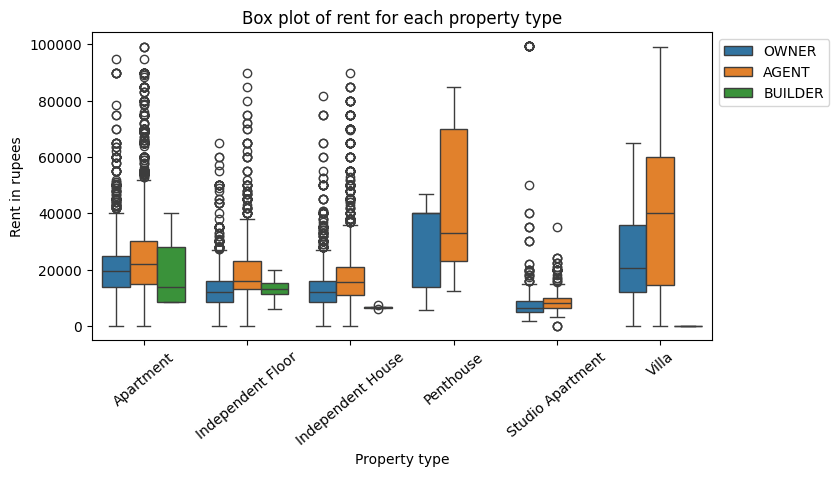

In [17]:
plt.figure(figsize = (8, 4))
sns.boxplot(
    data = df,
    x = 'property_type',
    y = 'price',
    order = sorted(list(df['property_type'].unique())),
    hue = 'seller_type'
)
plt.title('Box plot of rent for each property type')
plt.xlabel('Property type')
plt.xticks(rotation = 40)
plt.ylabel('Rent in rupees')
plt.legend(bbox_to_anchor = (1, 1))
plt.show()